<a href="https://colab.research.google.com/github/SoyOrnella/alurastore/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

df_total = pd.concat([tienda, tienda2, tienda3, tienda4])
print(df_total.head())

            Producto Categoría del Producto    Precio  Costo de envío  \
0  Asistente virtual           Electrónicos  164300.0          6900.0   
1    Mesa de comedor                Muebles  192300.0          8400.0   
2      Juego de mesa               Juguetes  209600.0         15900.0   
3         Microondas      Electrodomésticos  757500.0         41000.0   
4   Silla de oficina                Muebles  335200.0         20200.0   

  Fecha de Compra         Vendedor Lugar de Compra  Calificación  \
0      16/01/2021      Pedro Gomez          Bogotá             4   
1      18/05/2022  Beatriz Morales        Medellín             1   
2      15/03/2021   Juan Fernandez       Cartagena             1   
3      03/05/2022   Juan Fernandez            Cali             4   
4      07/11/2020    Maria Alfonso        Medellín             5   

       Método de pago  Cantidad de cuotas       lat       lon  
0  Tarjeta de crédito                   8   4.60971 -74.08175  
1  Tarjeta de crédito   

In [5]:
df_total['Monto total'] = df_total['Precio'] + df_total['Costo de envío']
total_facturacion = df_total['Monto total'].sum()
print(f"El monto total de facturación es: {total_facturacion:,.2f}")

El monto total de facturación es: 4,638,316,200.00


# 2. Ventas por categoría

In [6]:
ventas_por_categoria = df_total.groupby('Categoría del Producto')['Monto total'].sum().sort_values(ascending=False)
print("Ventas totales por categoría de producto:")
print(ventas_por_categoria)

Ventas totales por categoría de producto:
Categoría del Producto
Electrónicos               1.749039e+09
Electrodomésticos          1.395147e+09
Muebles                    7.981114e+08
Instrumentos musicales     3.672769e+08
Deportes y diversión       1.506693e+08
Juguetes                   7.762570e+07
Artículos para el hogar    6.069090e+07
Libros                     3.975600e+07
Name: Monto total, dtype: float64


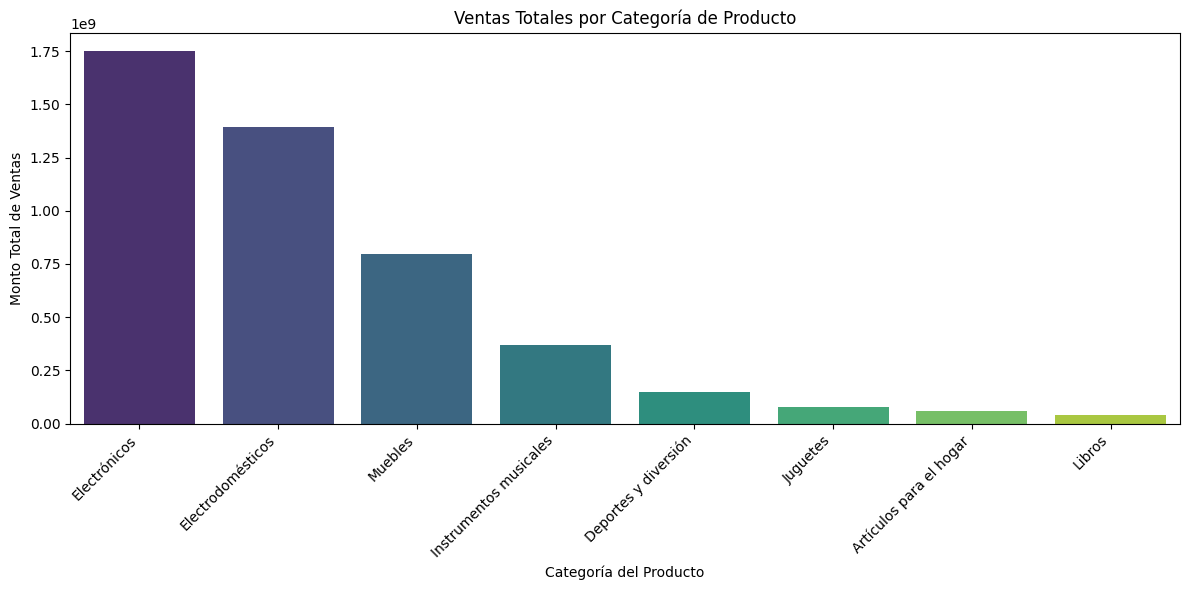

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=ventas_por_categoria.index, y=ventas_por_categoria.values, palette='viridis', hue=ventas_por_categoria.index, legend=False)
plt.title('Ventas Totales por Categoría de Producto')
plt.xlabel('Categoría del Producto')
plt.ylabel('Monto Total de Ventas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


In [9]:
calificacion_promedio = df_total['Calificación'].mean()
print(f"La calificación promedio general de la tienda es: {calificacion_promedio:.2f}")

La calificación promedio general de la tienda es: 4.01


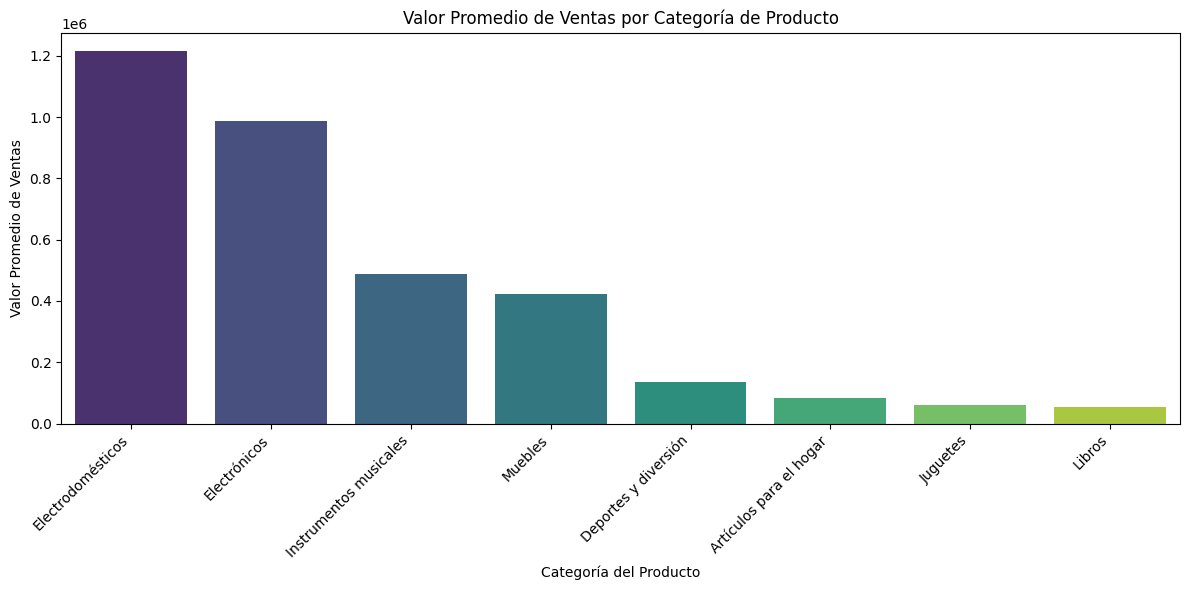

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=ventas_promedio_por_categoria.index, y=ventas_promedio_por_categoria.values, palette='viridis', hue=ventas_promedio_por_categoria.index, legend=False)
plt.title('Valor Promedio de Ventas por Categoría de Producto')
plt.xlabel('Categoría del Producto')
plt.ylabel('Valor Promedio de Ventas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
ventas_promedio_por_categoria = df_total.groupby('Categoría del Producto')['Monto total'].mean().sort_values(ascending=False)
print("Valor promedio de ventas por categoría de producto:")
print(ventas_promedio_por_categoria)

Valor promedio de ventas por categoría de producto:
Categoría del Producto
Electrodomésticos          1.214228e+06
Electrónicos               9.870421e+05
Instrumentos musicales     4.877515e+05
Muebles                    4.231768e+05
Deportes y diversión       1.353722e+05
Artículos para el hogar    8.313822e+04
Juguetes                   6.017496e+04
Libros                     5.357951e+04
Name: Monto total, dtype: float64


# 4. Productos más y menos vendidos

In [12]:
productos_vendidos = df_total['Producto'].value_counts()

producto_mas_vendido = productos_vendidos.index[0]
cantidad_mas_vendido = productos_vendidos.iloc[0]

producto_menos_vendido = productos_vendidos.index[-1]
cantidad_menos_vendido = productos_vendidos.iloc[-1]

print(f"El producto más vendido es: '{producto_mas_vendido}' con {cantidad_mas_vendido} unidades vendidas.")
print(f"El producto menos vendido es: '{producto_menos_vendido}' con {cantidad_menos_vendido} unidades vendidas.")

El producto más vendido es: 'Mesa de noche' con 210 unidades vendidas.
El producto menos vendido es: 'Celular ABXY' con 157 unidades vendidas.


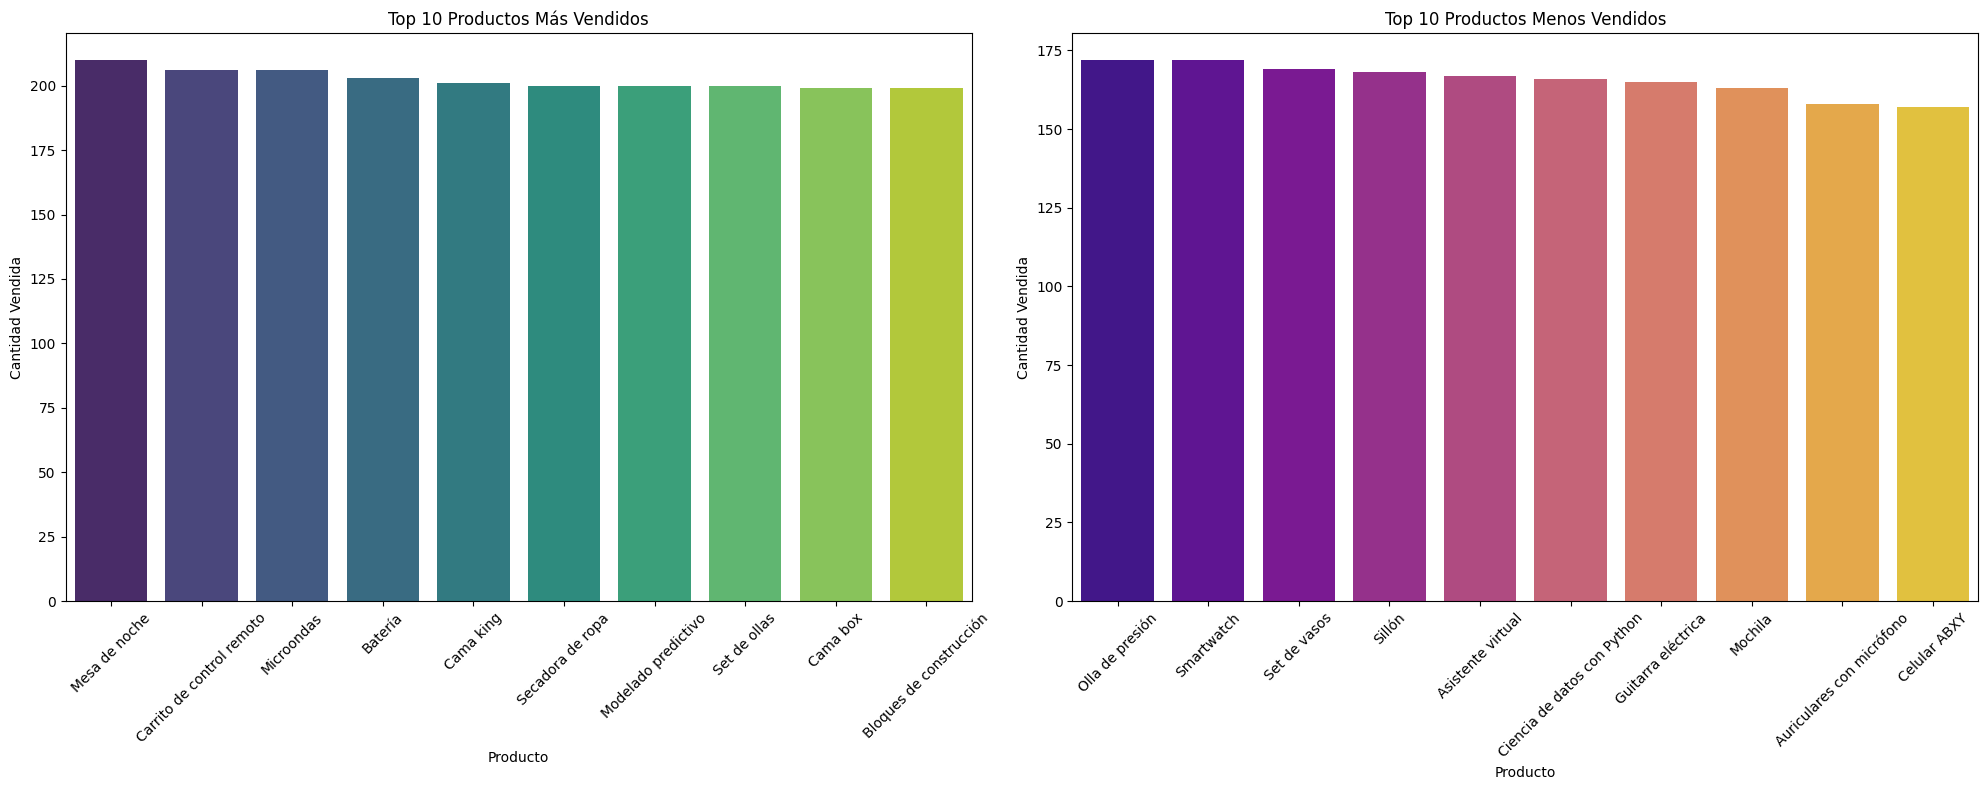

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener los 10 productos más vendidos y los 10 menos vendidos para una mejor visualización
productos_top_10 = productos_vendidos.head(10)
productos_bottom_10 = productos_vendidos.tail(10)

# Crear subplots para los productos más y menos vendidos
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Gráfico para los productos más vendidos
sns.barplot(x=productos_top_10.index, y=productos_top_10.values, palette='viridis', hue=productos_top_10.index, legend=False, ax=axes[0])
axes[0].set_title('Top 10 Productos Más Vendidos')
axes[0].set_xlabel('Producto')
axes[0].set_ylabel('Cantidad Vendida')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico para los productos menos vendidos
sns.barplot(x=productos_bottom_10.index, y=productos_bottom_10.values, palette='plasma', hue=productos_bottom_10.index, legend=False, ax=axes[1])
axes[1].set_title('Top 10 Productos Menos Vendidos')
axes[1].set_xlabel('Producto')
axes[1].set_ylabel('Cantidad Vendida')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

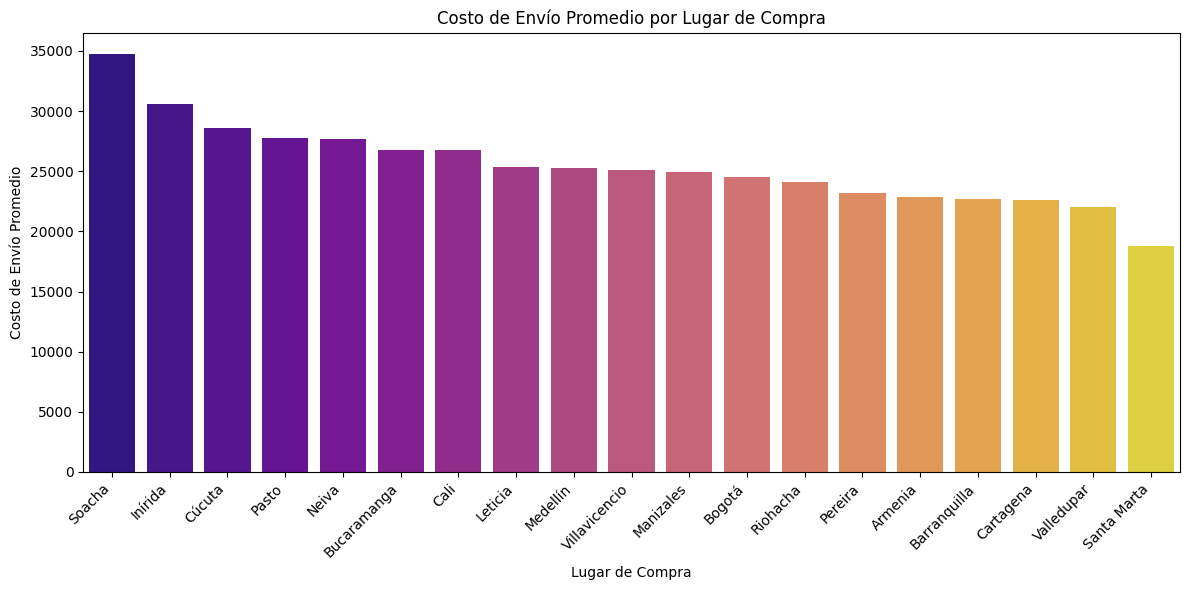

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=envio_promedio_por_tienda.index, y=envio_promedio_por_tienda.values, palette='plasma', hue=envio_promedio_por_tienda.index, legend=False)
plt.title('Costo de Envío Promedio por Lugar de Compra')
plt.xlabel('Lugar de Compra')
plt.ylabel('Costo de Envío Promedio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
envio_promedio_por_tienda = df_total.groupby('Lugar de Compra')['Costo de envío'].mean().sort_values(ascending=False)
print("Costo de envío promedio por tienda:")
print(envio_promedio_por_tienda)

Costo de envío promedio por tienda:
Lugar de Compra
Soacha           34768.421053
Inírida          30557.142857
Cúcuta           28597.311828
Pasto            27801.063830
Neiva            27710.000000
Bucaramanga      26790.055249
Cali             26726.812314
Leticia          25317.605634
Medellín         25282.022472
Villavicencio    25100.000000
Manizales        24948.780488
Bogotá           24532.082171
Riohacha         24127.607362
Pereira          23211.411992
Armenia          22867.857143
Barranquilla     22692.258065
Cartagena        22638.429752
Valledupar       22021.428571
Santa Marta      18752.317881
Name: Costo de envío, dtype: float64
